# 🚢 Titanic Dataset - Exploratory Data Analysis (EDA)

## Data Analysis with Python Internship - Task 3

**Intern:** Divyani Tripathi

### Project Objective
The objective of this project is to analyze the Titanic dataset, explore passenger characteristics, identify factors affecting survival, and visualize meaningful insights using Python.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

## 📂 Load Dataset

The Titanic dataset is loaded into a Pandas DataFrame for analysis.

In [33]:
df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 📊 Dataset Overview
Understanding the structure, dimensions, and statistical summary of the dataset.

In [34]:
print("Rows and Columns :", df.shape)

df.info()

df.describe()

Rows and Columns : (891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 🔍 Missing Value Analysis
Checking whether the dataset contains any missing values.

In [36]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Observation

No missing values were found in the dataset.
The dataset is already cleaned and ready for analysis.

## 🎯 Survival Analysis

This section analyzes how different passenger characteristics affected the survival rate.

In [37]:
survival_rate = df["Survived"].mean() * 100

print(f"Overall Survival Rate: {survival_rate:.2f}%")

Overall Survival Rate: 38.38%


### Observation

Approximately **38% of passengers survived**, while the majority did not survive the disaster.

In [43]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [44]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [45]:
df.drop("Cabin", axis=1, inplace=True)

In [46]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 19, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

In [47]:
df["FamilySize"] = df["SibSp"] + df["Parch"]

In [48]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Young Adult,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Adult,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Young Adult,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Young Adult,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Young Adult,0


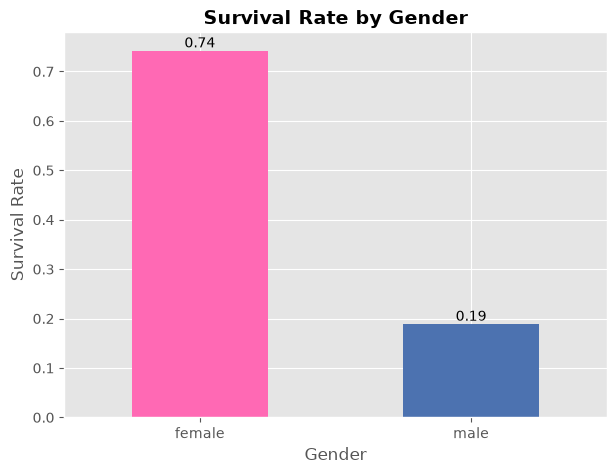

In [50]:
gender_survival = df.groupby("Sex")["Survived"].mean().sort_values(ascending=False)

plt.figure(figsize=(7,5))
ax = gender_survival.plot(kind="bar", color=["#ff69b4", "#4c72b0"])

plt.title("Survival Rate by Gender", fontsize=14, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.show()

### Observation

Female passengers had a much higher survival rate than male passengers.
This supports the historical "Women and Children First" evacuation policy.

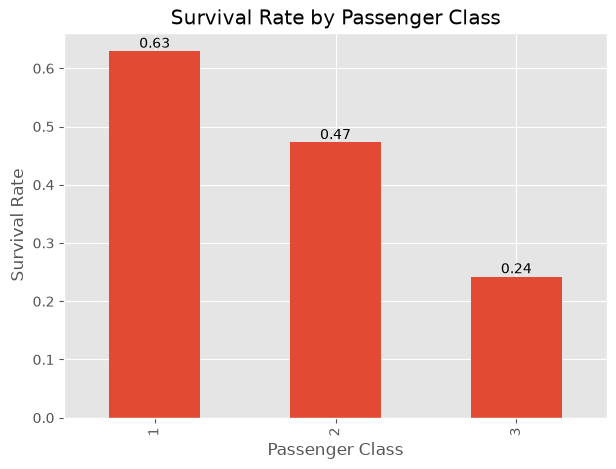

In [51]:
class_survival = df.groupby("Pclass")["Survived"].mean()

plt.figure(figsize=(7,5))

ax = class_survival.plot(kind="bar")

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.show()

### Observation

Passengers travelling in **First Class** had the highest survival rate, while **Third Class** passengers had the lowest.

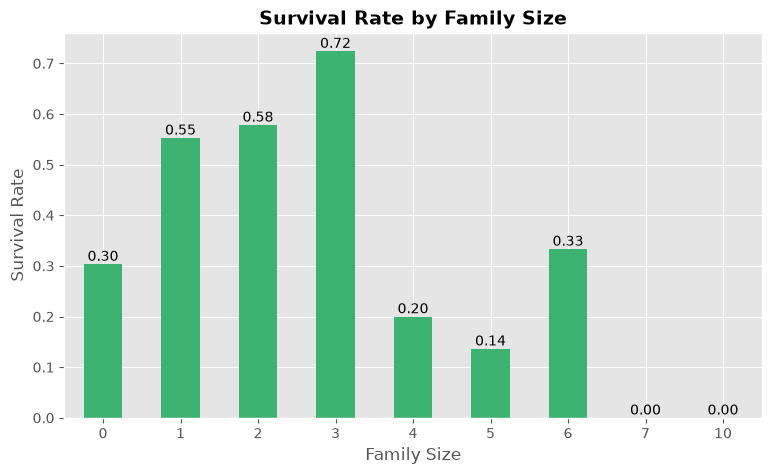

In [53]:
family_survival = df.groupby("FamilySize")["Survived"].mean()

plt.figure(figsize=(9,5))
ax = family_survival.plot(kind="bar", color="mediumseagreen")

plt.title("Survival Rate by Family Size", fontsize=14, fontweight="bold")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.show()

### Observation

Passengers travelling in **small families** generally had a better survival rate than those travelling alone or in very large families.

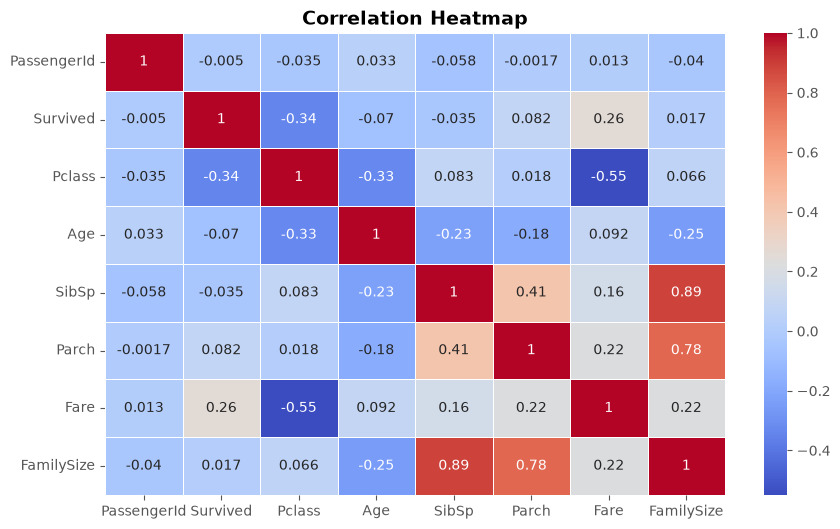

In [54]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")

plt.show()

# 📌 Key Insights

- The overall survival rate of passengers was around **38%**.
- Female passengers had a significantly higher survival rate than male passengers.
- First-class passengers were more likely to survive compared to second and third-class passengers.
- Children showed better survival rates than adults and senior passengers.
- Passengers travelling in small families had a higher chance of survival than those travelling alone or in very large families.
- Correlation analysis indicated that no single feature alone determined survival; multiple factors influenced the outcome.

# ✅ Conclusion

This project explored the Titanic dataset using Exploratory Data Analysis (EDA). Data preprocessing techniques such as handling missing values, feature engineering, and data visualization were applied to understand passenger survival patterns. The analysis revealed that gender, passenger class, age group, and family size significantly influenced survival rates. This project strengthened my understanding of data analysis, visualization, and extracting meaningful insights using Python.